# Practice 07 — DL Training Pipeline

Earlier models saw the whole dataset at every iteration.
From here on the updates run over **mini-batches**, and one pass through all of them is an **epoch**.

| Stage | What it produces |
|:---|:---|
| Data | train / validation / test split, standardized, wrapped in `DataLoader` |
| Model | an `nn.Module` returning logits |
| Loss + optimizer | `nn.CrossEntropyLoss`, `torch.optim.Adam` |
| `train` / `evaluate` | the epoch loop and the no-grad evaluation, written once |
| Diagnostics | learning curves, final test score, confusion matrix |

Steps 0-7 build that pipeline.
Steps 8-11 reuse it to compare a plain MLP with one carrying the four techniques usually added to it.

**Dataset.** `load_digits`: 1797 handwritten digits, each an $8 \times 8$ image flattened to 64 pixel
intensities, labelled 0-9.

---
## Step 0. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['axes.unicode_minus'] = False

# every tensor and every module is moved to this device; on a CPU-only machine .to(device) is a no-op
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


---
## Step 1. Data — Split, Then Standardize

| Set | In the training loop | Role |
|:---|:---|:---|
| Train (60%) | every batch | updates the weights |
| Validation (20%) | once per epoch | monitors generalization |
| Test (20%) | never | scored once, at the end |

$$x_i^{\text{new}} = \frac{x_i - \mu_i}{\sigma_i}$$

The split comes **first**; statistics taken before it would leak test information into training.
Pixels with $\sigma_i = 0$ stay unscaled, where a small epsilon would blow a test deviation up to order
$10^{8}$.

In [2]:
digits = load_digits()
X = digits.data                 # (1797, 64) pixel intensities, 0-16
y = digits.target               # (1797,) labels 0-9

print(f'X: {X.shape}, y: {y.shape}, classes: {np.unique(y)}')
display(pd.DataFrame(X, columns=[f'pixel_{i}' for i in range(X.shape[1])]).head(10))

X: (1797, 64), y: (1797,), classes: [0 1 2 3 4 5 6 7 8 9]


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_54,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
5,0.0,0.0,12.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,9.0,16.0,16.0,10.0,0.0,0.0
6,0.0,0.0,0.0,12.0,13.0,0.0,0.0,0.0,0.0,0.0,...,8.0,0.0,0.0,0.0,1.0,9.0,15.0,11.0,3.0,0.0
7,0.0,0.0,7.0,8.0,13.0,16.0,15.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,13.0,5.0,0.0,0.0,0.0,0.0
8,0.0,0.0,9.0,14.0,8.0,1.0,0.0,0.0,0.0,0.0,...,8.0,0.0,0.0,0.0,11.0,16.0,15.0,11.0,1.0,0.0
9,0.0,0.0,11.0,12.0,0.0,0.0,0.0,0.0,0.0,2.0,...,4.0,0.0,0.0,0.0,9.0,12.0,13.0,3.0,0.0,0.0


In [3]:
# 60 / 20 / 20 split, stratified so every class keeps its proportion
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0)
train_std[train_std == 0] = 1.0   # leave zero-variance features unscaled

X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std   # statistics from the training set
X_test  = (X_test  - train_mean) / train_std   # statistics from the training set

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'constant pixels in the training set: {(train_std == 1.0).sum()}')
print(f'train mean/std after scaling: {X_train.mean():.4f} / {X_train.std():.4f}')

Train: (1078, 64), Val: (359, 64), Test: (360, 64)
constant pixels in the training set: 4
train mean/std after scaling: 0.0000 / 0.9682


---
## Step 2. `TensorDataset` and `DataLoader`

`TensorDataset` pairs inputs with labels, `DataLoader` cuts that into batches.
Labels are `LongTensor`, the `int64` `CrossEntropyLoss` expects.

| Term | Meaning | Here |
|:---|:---|:---|
| Batch size | samples per weight update | 16 |
| Iteration | one weight update | one batch |
| Epoch | one pass over the training set | $\lceil 1078 / 16 \rceil = 68$ iterations |

Only the training loader shuffles, so `y_pred` stays aligned with `y_val` and `y_test`.

In [4]:
train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)),
    batch_size=16, shuffle=True)
val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)),
    batch_size=16, shuffle=False)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)),
    batch_size=16, shuffle=False)

print(f'batches per epoch - train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

X_batch, Y_batch = next(iter(train_loader))
print(f'one batch - X {tuple(X_batch.shape)} {X_batch.dtype}, Y {tuple(Y_batch.shape)} {Y_batch.dtype}')

batches per epoch - train: 68, val: 23, test: 23
one batch - X (16, 64) torch.float32, Y (16,) torch.int64


---
## Step 3. Model

A three-layer MLP, $64 \to 128 \to 128 \to 10$.
The last layer has one unit per class and returns raw logits — `nn.CrossEntropyLoss` applies the softmax
internally, so no activation follows it.

`.to(device)` is called **before** the optimizer is created, so the optimizer holds the parameters that
actually take part in the computation.

In [5]:
class DigitMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        z = self.net(x)      # logits; the softmax is applied inside the loss
        return z


torch.manual_seed(42)
model_baseline = DigitMLP().to(device)
print(model_baseline)
print()
print(f'Total parameters: {sum(p.numel() for p in model_baseline.parameters()):,}')

DigitMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 26,122


---
## Step 4. Loss and Optimizer

`nn.CrossEntropyLoss` combines softmax and the negative log-likelihood

$$o_k = \frac{e^{z_k}}{\sum_q e^{z_q}}, \qquad J = -\log o_{y}$$

into one call on the logits.
Adam keeps a per-parameter estimate of the gradient and its square, which converges in fewer epochs here
than plain SGD.
Its argument is the API name `lr`, passed `rho` so the learning rate is visibly the $\rho$ of the update
rule.

In [6]:
rho    = 0.001
epochs = 50

optimizer_baseline = torch.optim.Adam(model_baseline.parameters(), lr=rho)

print(f'Loss      : {nn.CrossEntropyLoss()}')
print(f'Optimizer : Adam (lr = {rho})')
print(f'Epochs    : {epochs}')

Loss      : CrossEntropyLoss()
Optimizer : Adam (lr = 0.001)
Epochs    : 50


---
## Step 5. `train` and `evaluate`

| Function | Returns |
|:---|:---|
| `train(model, train_loader, val_loader, optimizer, epochs, device)` | `(train_losses, train_accs, val_losses, val_accs)` |
| `evaluate(model, loader, device)` | `(loss, accuracy, y_pred)` |

- `train` monitors on `val_loader` only; `test_loader` in the loop would let the test set steer the model,
  and the final number would stop measuring generalization.
- `model.train()` / `model.eval()` switch dropout and batch normalization, inside the functions so no caller
  can forget.

`evaluate` makes one pass over a loader with the gradient turned off.

In [7]:
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, count = 0.0, 0, 0
    preds = []
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            output = model(X_batch)
            loss_sum += criterion(output, Y_batch).item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
            preds.append(output.argmax(1).cpu())

    y_pred = torch.cat(preds).numpy()
    return loss_sum / len(loader), correct / count, y_pred

`train` runs the epoch loop and calls `evaluate` on `val_loader` after each epoch.

In [8]:
def train(model, train_loader, val_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    train_losses, train_accs, val_losses, val_accs = [], [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            output = model(X_batch)               # logits, (batch, 10)
            loss = criterion(output, Y_batch)

            optimizer.zero_grad()                 # clear the accumulated gradients
            loss.backward()                       # autograd computes the gradients
            optimizer.step()                      # the optimizer updates the parameters

            loss_sum += loss.item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)

        train_loss = loss_sum / len(train_loader)
        train_acc = correct / count
        val_loss, val_acc, _ = evaluate(model, val_loader, device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs}  '
                  f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
                  f'train_acc={train_acc:.4f}  val_acc={val_acc:.4f}')
    return train_losses, train_accs, val_losses, val_accs

---
## Step 6. Training the Baseline

The whole pipeline is now one call.

In [9]:
train_losses_baseline, train_accs_baseline, val_losses_baseline, val_accs_baseline = train(
    model_baseline, train_loader, val_loader, optimizer_baseline, epochs=epochs, device=device)

print()
print(f'Baseline final  train_loss={train_losses_baseline[-1]:.4f}  val_loss={val_losses_baseline[-1]:.4f}  '
      f'train_acc={train_accs_baseline[-1]:.4f}  val_acc={val_accs_baseline[-1]:.4f}')

  Epoch   1/50  train_loss=1.4448  val_loss=0.5404  train_acc=0.6698  val_acc=0.8747


  Epoch  10/50  train_loss=0.0059  val_loss=0.0984  train_acc=1.0000  val_acc=0.9721


  Epoch  20/50  train_loss=0.0012  val_loss=0.0989  train_acc=1.0000  val_acc=0.9721


  Epoch  30/50  train_loss=0.0004  val_loss=0.1043  train_acc=1.0000  val_acc=0.9721


  Epoch  40/50  train_loss=0.0002  val_loss=0.1095  train_acc=1.0000  val_acc=0.9721


  Epoch  50/50  train_loss=0.0001  val_loss=0.1140  train_acc=1.0000  val_acc=0.9721

Baseline final  train_loss=0.0001  val_loss=0.1140  train_acc=1.0000  val_acc=0.9721


---
## Step 7. Learning Curves

Loss on the left, accuracy on the right, each with the train and the validation curve.
The gap between the two is what overfitting looks like: the training loss keeps falling while the validation
loss flattens and then turns upward.
The train curve is an epoch average, taken while the weights were still changing.

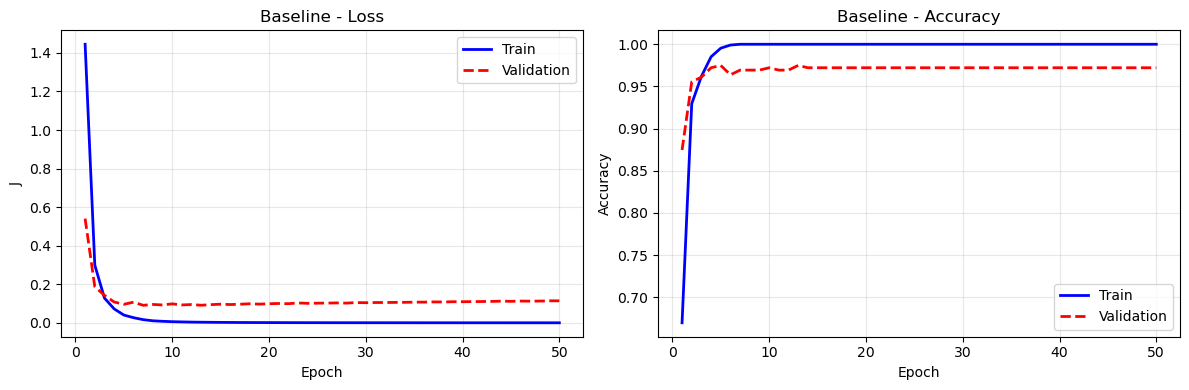

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, epochs + 1)

axes[0].plot(epochs_range, train_losses_baseline, 'b-',  linewidth=2, label='Train')
axes[0].plot(epochs_range, val_losses_baseline,   'r--', linewidth=2, label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('J')
axes[0].set_title('Baseline - Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, train_accs_baseline, 'b-',  linewidth=2, label='Train')
axes[1].plot(epochs_range, val_accs_baseline,   'r--', linewidth=2, label='Validation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Baseline - Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## Step 8. An Improved Model

Four techniques are almost always present in a trained network.
They are added here as a group.

| Technique | What it does |
|:---|:---|
| He (Kaiming) initialization | scales the initial weights by $\sqrt{2/n_{\text{in}}}$, the variance matched to ReLU |
| `nn.BatchNorm1d` | standardizes each unit's pre-activation over the batch |
| `nn.Dropout(0.3)` | zeroes 30% of the units at random while training |
| Weight decay $10^{-3}$ | adds $\lambda\lVert\mathbf{w}\rVert_2^2$ through Adam's `weight_decay` |

Held fixed: the same loaders, widths 128 and 128, Adam at $\rho = 0.001$, batch size 16, 50 epochs,
`torch.manual_seed(42)` before construction.

| Changed | Baseline | Improved |
|:---|:---|:---|
| Initialization | PyTorch default | He (Kaiming normal) |
| Normalization layer | none | `BatchNorm1d(128)` |
| Dropout | none | $p = 0.3$ |
| Weight decay | 0 | $10^{-3}$ |

> Four things change at once, so the result shows what the **group** is worth, not how much each member
> contributed.

In [11]:
class DigitMLPImproved(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10),
        )
        # He initialization, matched to the ReLU that follows each linear layer
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')

    def forward(self, x):
        z = self.net(x)
        return z


torch.manual_seed(42)
model_improved = DigitMLPImproved().to(device)
optimizer_improved = torch.optim.Adam(model_improved.parameters(), lr=rho, weight_decay=1e-3)

print(model_improved)
print()
print(f'Total parameters: {sum(p.numel() for p in model_improved.parameters()):,}')

DigitMLPImproved(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 26,634


In [12]:
train_losses_improved, train_accs_improved, val_losses_improved, val_accs_improved = train(
    model_improved, train_loader, val_loader, optimizer_improved, epochs=epochs, device=device)

print()
print(f'Improved final  train_loss={train_losses_improved[-1]:.4f}  val_loss={val_losses_improved[-1]:.4f}  '
      f'train_acc={train_accs_improved[-1]:.4f}  val_acc={val_accs_improved[-1]:.4f}')

  Epoch   1/50  train_loss=1.9785  val_loss=0.9182  train_acc=0.3544  val_acc=0.8691


  Epoch  10/50  train_loss=0.2914  val_loss=0.1386  train_acc=0.9221  val_acc=0.9721


  Epoch  20/50  train_loss=0.1437  val_loss=0.0983  train_acc=0.9666  val_acc=0.9666


  Epoch  30/50  train_loss=0.0907  val_loss=0.0904  train_acc=0.9759  val_acc=0.9749


  Epoch  40/50  train_loss=0.0847  val_loss=0.0896  train_acc=0.9824  val_acc=0.9833


  Epoch  50/50  train_loss=0.0891  val_loss=0.0809  train_acc=0.9740  val_acc=0.9805

Improved final  train_loss=0.0891  val_loss=0.0809  train_acc=0.9740  val_acc=0.9805


---
## Step 9. Baseline vs Improved

Only the validation curves are drawn.
They are the ones that speak about generalization, and four curves on one axis would hide exactly the
difference being looked for.

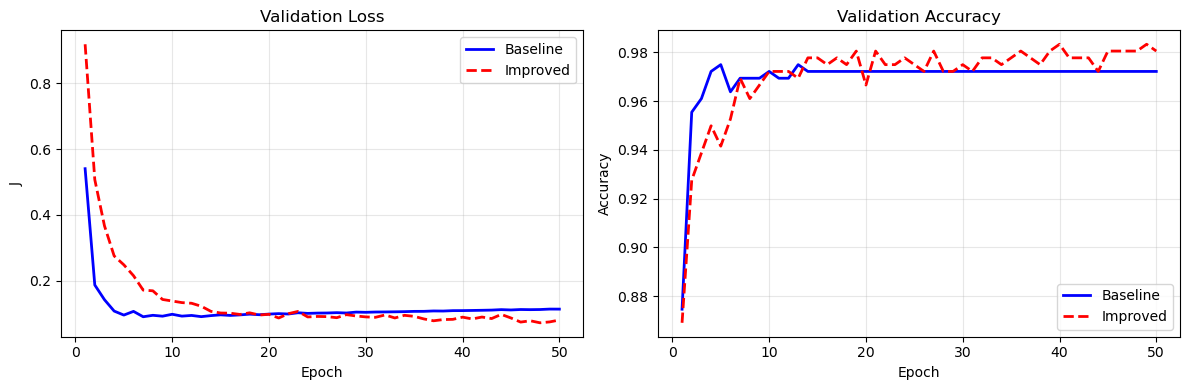

best val_acc  - baseline: 0.9749, improved: 0.9833
final val_loss - baseline: 0.1140, improved: 0.0809


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, val_losses_baseline, 'b-',  linewidth=2, label='Baseline')
axes[0].plot(epochs_range, val_losses_improved, 'r--', linewidth=2, label='Improved')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('J')
axes[0].set_title('Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, val_accs_baseline, 'b-',  linewidth=2, label='Baseline')
axes[1].plot(epochs_range, val_accs_improved, 'r--', linewidth=2, label='Improved')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'best val_acc  - baseline: {max(val_accs_baseline):.4f}, improved: {max(val_accs_improved):.4f}')
print(f'final val_loss - baseline: {val_losses_baseline[-1]:.4f}, improved: {val_losses_improved[-1]:.4f}')

---
## Step 10. Final Test Evaluation

Training is over and no further choice will be made from these numbers, so the test set is read now — once,
for each model.

In [14]:
test_loss_baseline, test_acc_baseline, y_pred_baseline = evaluate(model_baseline, test_loader, device)
test_loss_improved, test_acc_improved, y_pred_improved = evaluate(model_improved, test_loader, device)

print(f'Baseline  test_loss={test_loss_baseline:.4f}  test_acc={test_acc_baseline:.4f}')
print(f'Improved  test_loss={test_loss_improved:.4f}  test_acc={test_acc_improved:.4f}')

Baseline  test_loss=0.1253  test_acc=0.9778
Improved  test_loss=0.0836  test_acc=0.9778


Accuracy over 360 test samples moves in steps of one sample, 0.28 %p, so it is a coarse instrument: two
models can land on the same accuracy while their losses differ clearly.
The loss also carries how confident the correct answers were, which is what separates the two models here.

---
## Step 11. Where the Errors Are

A single accuracy figure says how many samples are wrong, not which ones.
The predictions returned by `evaluate` are reused here, so nothing is predicted twice.

- the first four misclassified test images, titled `True` / `Pred`
- the confusion matrix, whose off-diagonal entries name the pairs of digits being confused

misclassified: 8 of 360 test samples


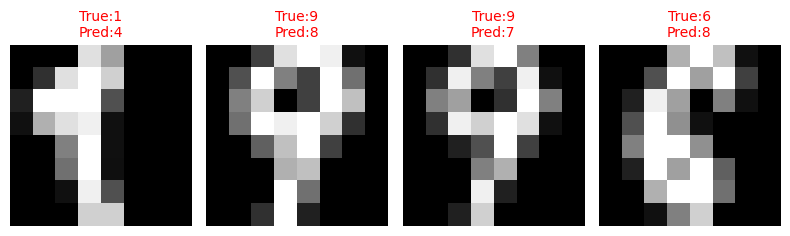

In [15]:
# undo the standardization to recover the original 0-16 pixel scale for display
X_test_display = X_test * train_std + train_mean
wrong_index = np.where(y_pred_improved != y_test)[0]
print(f'misclassified: {len(wrong_index)} of {len(y_test)} test samples')

fig, axes = plt.subplots(1, 4, figsize=(8, 2.5))
for i in range(4):
    index = wrong_index[i]
    axes[i].imshow(X_test_display[index].reshape(8, 8), cmap='gray')
    axes[i].set_title(f'True:{y_test[index]}\nPred:{y_pred_improved[index]}', color='red', fontsize=10)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

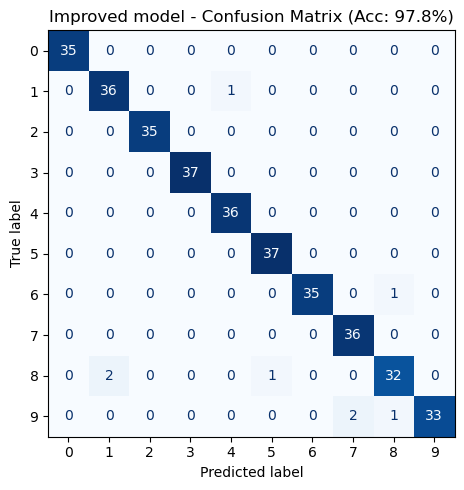

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_improved), display_labels=range(10))
display_matrix.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Improved model - Confusion Matrix (Acc: {test_acc_improved:.1%})')
plt.tight_layout(); plt.show()

---
## Summary

- The training loop watches the validation set only.
  The test set is read once, at the end, and never influences a choice.
- `train` and `evaluate` name neither the model nor the dataset, which is why the second model needed no new
  training code.
- The baseline drove its training loss to nearly zero while the validation loss turned upward; the four
  techniques together kept it falling, as a group that says nothing about which member mattered.

---
## Exercises

1. Set `batch_size` to 4, then 256, keeping `epochs = 50`.
   What changes in the iterations per epoch, the run time and the loss curve?
2. Switch to `torch.optim.SGD(..., lr=rho)`.
   How many epochs to reach what Adam reached in 50?
3. Turn on one of the four techniques at a time.
   Which accounts for most of the improvement?
4. Train the baseline on 10% of the training set.
   What do the two loss curves do?

In [17]:
# Write your code here